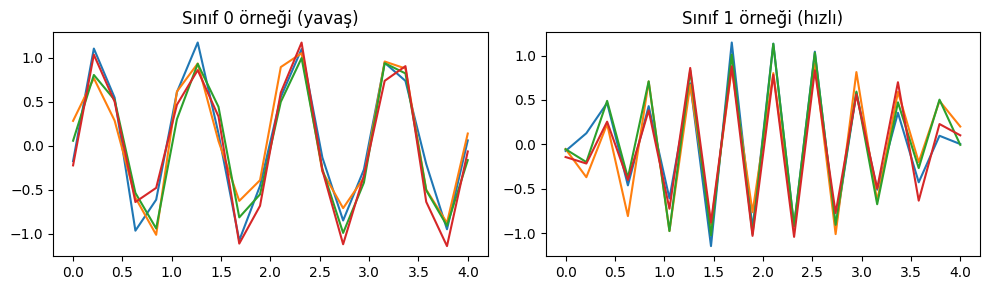

Veri shape: (200, 4, 20)


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)

C, T, N = 4, 20, 200   # 4 kanal, 20 zaman noktası, 200 örnek
t_axis = np.linspace(0, 4, T)

def make_sample(label):
    freq = 1.0 if label==0 else 2.5   # sınıf 0: yavaş salınım, sınıf 1: hızlı salınım
    base = np.sin(2*np.pi*freq*t_axis)
    signal = np.stack([base + 0.15*np.random.randn(T) for _ in range(C)])
    return signal

labels = np.random.randint(0,2,N)
data = np.stack([make_sample(l) for l in labels])   # (N, C, T)

fig, axes = plt.subplots(1,2, figsize=(10,3))
axes[0].plot(t_axis, data[labels==0][0].T); axes[0].set_title("Sınıf 0 örneği (yavaş)")
axes[1].plot(t_axis, data[labels==1][0].T); axes[1].set_title("Sınıf 1 örneği (hızlı)")
plt.tight_layout(); plt.show()
print("Veri shape:", data.shape)

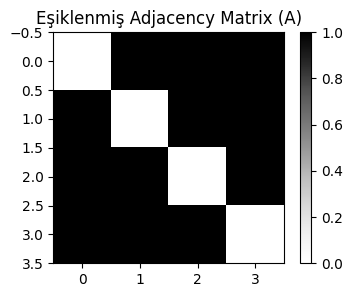

A:
 [[0. 1. 1. 1.]
 [1. 0. 1. 1.]
 [1. 1. 0. 1.]
 [1. 1. 1. 0.]]


In [ ]:
from sklearn.feature_selection import mutual_info_regression

avg_signal = data.mean(axis=0)   # (C, T) — örnekler üzerinden ortalama, sadece graph yapısı için
MI = np.zeros((C,C))
for i in range(C):
    for j in range(C):
        if i!=j:
            MI[i,j] = mutual_info_regression(avg_signal[i].reshape(-1,1), avg_signal[j], random_state=0)[0]

threshold = 0.05
A = (MI > threshold).astype(float)
np.fill_diagonal(A, 0)

plt.figure(figsize=(4,3))
plt.imshow(A, cmap='Greys')
plt.title("Eşiklenmiş Adjacency Matrix (A)")
plt.colorbar()
plt.show()
print("A:\n", A)

In [ ]:
class GraphGRUCell(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.input_proj = nn.Linear(1, d)          # her zaman adımındaki skaler değeri d boyuta çıkarır
        self.w_alpha = nn.Parameter(torch.randn(2*d))
        self.Wr = nn.Linear(d, d); self.Ur = nn.Linear(d, d)
        self.Wz = nn.Linear(d, d); self.Uz = nn.Linear(d, d)
        self.Wh = nn.Linear(d, d); self.Uh = nn.Linear(d, d)

    def attention_aggregate(self, x_t, A):
        C = x_t.shape[0]
        scores = torch.full((C,C), float('-inf'))
        for v in range(C):
            for u in range(C):
                if A[v,u] > 0:
                    z = F.leaky_relu(torch.dot(self.w_alpha, torch.cat([x_t[v], x_t[u]])))
                    scores[v,u] = z
        alpha = F.softmax(scores, dim=1)
        alpha = torch.nan_to_num(alpha)   # izole node varsa NaN önle
        return alpha @ x_t   # (C, d)

    def forward(self, raw, A):
        # raw: (C, T)
        C, T = raw.shape
        d = self.input_proj.out_features
        h = torch.zeros(C, d)
        for t in range(T):
            x_t = self.input_proj(raw[:, t].unsqueeze(1))   # (C, d)
            a_t = self.attention_aggregate(x_t, A)           # Eş. 4-6
            r = torch.sigmoid(self.Wr(a_t) + self.Ur(h))
            z = torch.sigmoid(self.Wz(a_t) + self.Uz(h))
            h_tilde = torch.tanh(self.Wh(a_t) + self.Uh(r*h))
            h = (1-z)*h_tilde + z*h
        return h.mean(dim=0)   # Eş. 11: C kanal üzerinden ortalama -> global feature

class GlobalBranch(nn.Module):
    def __init__(self, d=8, n_classes=2):
        super().__init__()
        self.graph_gru = GraphGRUCell(d)
        self.classifier = nn.Linear(d, n_classes)

    def forward(self, raw, A):
        h_bar = self.graph_gru(raw, A)         # global feature
        logits = self.classifier(h_bar)         # Eş. 12 (softmax cross-entropy içinde uygulanacak)
        return logits, h_bar

Epoch 0: loss = 0.6142
Epoch 5: loss = 0.0016
Epoch 10: loss = 0.0006
Epoch 15: loss = 0.0003
Epoch 20: loss = 0.0002
Epoch 25: loss = 0.0002


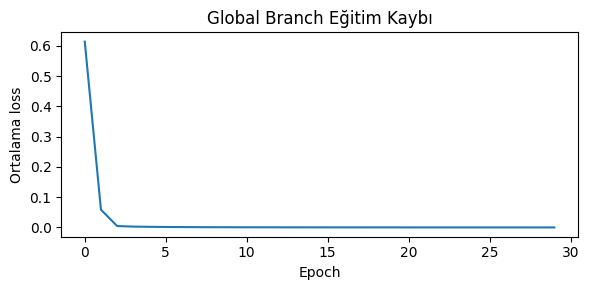

In [ ]:
model = GlobalBranch(d=8)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
A_t = torch.tensor(A, dtype=torch.float32)

losses = []
n_epochs = 30
for epoch in range(n_epochs):
    epoch_loss = 0
    perm = np.random.permutation(N)[:40]   # her epoch'ta 40 örnekle hızlı eğitim
    for idx in perm:
        raw = torch.tensor(data[idx], dtype=torch.float32)
        y = torch.tensor([labels[idx]])
        optimizer.zero_grad()
        logits, _ = model(raw, A_t)
        loss = F.cross_entropy(logits.unsqueeze(0), y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss/len(perm))
    if epoch % 5 == 0:
        print(f"Epoch {epoch}: loss = {losses[-1]:.4f}")

plt.figure(figsize=(6,3))
plt.plot(losses)
plt.xlabel("Epoch"); plt.ylabel("Ortalama loss")
plt.title("Global Branch Eğitim Kaybı")
plt.tight_layout(); plt.show()

Tüm global feature'ların shape'i: (200, 8)


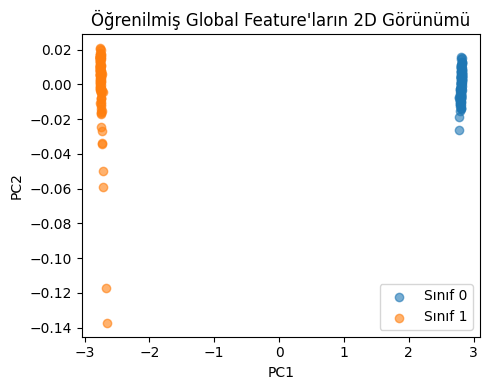

In [ ]:
model.eval()
with torch.no_grad():
    all_h = []
    for idx in range(N):
        raw = torch.tensor(data[idx], dtype=torch.float32)
        _, h_bar = model(raw, A_t)
        all_h.append(h_bar.numpy())
all_h = np.array(all_h)   # (N, d)
print("Tüm global feature'ların shape'i:", all_h.shape)

# 8 boyutlu embedding'i 2 boyuta indirip görselleştirelim (PCA)
from sklearn.decomposition import PCA
h_2d = PCA(n_components=2).fit_transform(all_h)

plt.figure(figsize=(5,4))
plt.scatter(h_2d[labels==0,0], h_2d[labels==0,1], label='Sınıf 0', alpha=0.6)
plt.scatter(h_2d[labels==1,0], h_2d[labels==1,1], label='Sınıf 1', alpha=0.6)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Öğrenilmiş Global Feature'ların 2D Görünümü")
plt.legend()
plt.tight_layout(); plt.show()